In [ ]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy
import matplotlib.pyplot as plt
from cobra import Model
import os
import time
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# agora_dir_base = '/Users/david/Dropbox/My_Stuff/UVM_2/Lab/Projects/AGORA2_Metabolic_Models/'
agora_dir_base = "/home/rseag/AGORA2_Models/"
agora_dirs = ['AGORA2_annotatedMat_A_C', 'AGORA2_annotatedMat_D_F', 'AGORA2_annotatedMat_G_P', 'AGORA2_annotatedMat_R_Y']


In [3]:
# store results in a pd df, store N models (model names too), N_unique rxns, sum(N_rxns per model), N unique metabolites, sum(N_metabolites per model)
results_df = pd.DataFrame(columns=["N_models", 
                                   "solver",
                                   "model_names", 
                                   "sum_N_rxns", 
                                   "sum_N_mets", 
                                   "gifba_solve_time", 
                                   "solve_ivp_time", 
                                   "gifba_fba_calls", 
                                   "dfba_fba_calls"])



In [4]:
# AGORA models
# Load N random models
N = 2

# count number of files in each directory
file_counts = []
for dir in agora_dirs:
    path = os.path.join(agora_dir_base, dir)
    count = len([name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))])
    file_counts.append(count)

# randomly select N models across all directories weighting by the number of files in each directory
selected_models = []
for i in range(N):
    # randomly select a directory based on file counts
    dir_index = np.random.choice(len(agora_dirs), p=np.array(file_counts)/sum(file_counts))
    dir = agora_dirs[dir_index]
    path = os.path.join(agora_dir_base, dir)
    
    # randomly select a model from the selected directory
    model_files = [name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))]
    model_file = np.random.choice(model_files)
    
    # load the model
    model_path = os.path.join(path, model_file)
    model = cb.io.load_matlab_model(model_path)
    
    selected_models.append(model)



Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [5]:
# AGORA models
AH_path = "/home/rseag/UVM/M3_Lab/giFBA/Examples/2_real_models/data/Eubacterium_hallii_DSM_3353.mat"
BI_path = "/home/rseag/UVM/M3_Lab/giFBA/Examples/2_real_models/data/Bifidobacterium_longum_infantis_ATCC_15697.mat"

# AH_path = "../../AGORA2_Models/Eubacterium_hallii_DSM_3353.mat"
# BI_path = "../../AGORA2_Models/Bifidobacterium_longum_infantis_ATCC_15697.mat"

AH = cb.io.load_matlab_model(AH_path)
BI = cb.io.load_matlab_model(BI_path)

selected_models = [BI, AH]
ids_list = ["BI", "AH"]
rel_abund = [0.5, 0.5]

media = {
	'EX_o2(e)': 0, #aerobic/anaerobic
	'EX_h2o(e)': -1000,
	'EX_pi(e)': -1000,
	'EX_fe2(e)': -1000,
	'EX_fe3(e)': -1000,
	'EX_zn2(e)': -1000,
	'EX_so4(e)': -1000,
	'EX_cu2(e)': -1000,
	'EX_k(e)': -1000,
	'EX_mg2(e)': -1000,
	'EX_mn2(e)': -1000,
	'EX_cd2(e)': -1000,
	'EX_cl(e)': -1000,
	'EX_ca2(e)': -1000,
	'EX_cobalt2(e)': -1000,
	'EX_glc_D(e)': -10,
	'EX_nh4(e)': -20,

	'EX_ribflv(e)': -1000,
	'EX_pnto_R(e)': -1000,
	'EX_nac(e)': -1000,
	'EX_his_L(e)': -1000,
	'EX_asn_L(e)': -1000,
	'EX_glycys(e)': -1000,

	'EX_lys_L(e)': -1000,
	'EX_ala_L(e)': -1000,
	'EX_met_L(e)': -1000,
	'EX_leu_L(e)': -1000,
	'EX_hxan(e)': -1000,    
    'EX_glyglu(e)': -1000
}

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [6]:
for i, model in enumerate(selected_models):
    for ex in model.exchanges:
        if "ex_biomass" in ex.id.lower():
            print(f"Model {i}: {model.id}, Biomass exchange: {ex.id}")

Model 0: model, Biomass exchange: EX_biomass(e)
Model 1: model, Biomass exchange: EX_biomass(e)


In [7]:
def rename_community_biomass(models, old_biomass_id="EX_Bio(e)"):
    """
    Renames the biomass exchange reactions and their associated metabolites 
    to track individual species separately.
    """
    # Deepcopy ensures we don't accidentally modify the original template models
    updated_models = copy.deepcopy(models)
    
    for idx, model in enumerate(updated_models):
        suffix = f"_{idx + 1}"  # e.g., _1, _2
        
        if old_biomass_id in model.reactions:
            # 1. Isolate the biomass reaction
            biomass_rxn = model.reactions.get_by_id(old_biomass_id)
            
            # 2. Rename the associated biomass metabolite(s) FIRST
            # We cast to list() to avoid modifying a dictionary while iterating over it
            for metabolite in list(biomass_rxn.metabolites):
                metabolite.id = f"{metabolite.id}{suffix}"
                # Optional: update the metabolite name for clarity
                metabolite.name = f"{metabolite.name} (Species {idx + 1})"
            
            # 3. Rename the reaction itself
            biomass_rxn.id = f"{old_biomass_id}{suffix}"
            biomass_rxn.name = f"{biomass_rxn.name} (Species {idx + 1})"
            
    return updated_models

In [8]:
renamed_models = rename_community_biomass(selected_models, old_biomass_id="EX_biomass(e)")

Read LP format model from file /tmp/tmp7hfonb4c.lp
Reading time = 0.00 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmp6nqlk3xo.lp
Reading time = 0.00 seconds
: 980 rows, 2102 columns, 8980 nonzeros


In [9]:
# Initialize giFBA object
# assigne equal relative abundance to each model
rel_abund = np.ones(N) / N
# rel_abund = [0.2, 0.8]
# rel_abund = [0.3, 0.7]

# define medium

# euro_media = "../Examples/2_real_models/data/euro_diet.tsv"
# euro_media = pd.read_csv(euro_media, sep="\t", header=0, index_col=0).to_dict()
# euro_media = euro_media["Flux Value"]
# euro_media = {ex.replace("[e]", "(e)"): -flux for ex, flux in euro_media.items()}

# community = gifba.gifbaObject(renamed_models, [euro_media, 0.1], # minimal media
#                             rel_abund=rel_abund)

# models, media = gifba.utils.load_simple_models("5_2_dynamical")
# renamed_models = rename_community_biomass(models, old_biomass_id="EX_Bio(e)")
community = gifba.gifbaObject(renamed_models, media, rel_abund=rel_abund)
# env_flux, org_flux = community.run_gifba(iters=100, method="pfba")
# print(community.periodicity)


Read LP format model from file /tmp/tmppdap6rf0.lp
Reading time = 0.00 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmp7qffakhp.lp
Reading time = 0.00 seconds
: 980 rows, 2102 columns, 8980 nonzeros


In [10]:
import pandas as pd
import numpy as np
from tqdm import tqdm
# n_dfba_fba_calls = 0  # Global counter for FBA calls during DFBA
def dsdt(t, S, models, vmax, km, media_keys, rel_abund, record_fluxes=None):
    global n_dfba_fba_calls
    dsdt_rates = np.zeros(len(S))
    conc_map = dict(zip(media_keys, S))
    
    # Collect fluxes for logging if a list is provided
    model_flux_records = {} if record_fluxes is not None else None
    
    for mdl_idx, model in enumerate(models):
        for ex_id in media_keys:
            if ex_id in model.reactions and "bio" not in ex_id:
                v_max = vmax.loc[str(mdl_idx), ex_id]
                k_m = km.loc[str(mdl_idx), ex_id]
                c = conc_map[ex_id]
                
                if c < 1e-6:
                    c = 0.0

                uptake_limit = (v_max * c) / (k_m + c)
                model.reactions.get_by_id(ex_id).lower_bound = -uptake_limit

        # use pfba to get the optimal flux distribution
        solution = cb.flux_analysis.parsimonious.pfba(model)
        # solution = model.optimize()
        n_dfba_fba_calls += 1  # Increment the global FBA call counter

        if solution.status == 'optimal':
            # Save fluxes for this specific model if recording
            if model_flux_records is not None:
                # scale fluxes by relative abundance
                scaled_fluxes = {rxn: flux * rel_abund[mdl_idx] for rxn, flux in solution.fluxes.items()}
                model_flux_records[mdl_idx] = scaled_fluxes
                
            for i, ex_id in enumerate(media_keys):
                flux_per_hr = solution.fluxes.get(ex_id, 0)
                dsdt_rates[i] += flux_per_hr * rel_abund[mdl_idx]
        else:
            if model_flux_records is not None:
                model_flux_records[mdl_idx] = {}

    for i, ex_id in enumerate(media_keys):
        media_flux = community.env_fluxes.loc[0, ex_id]
        dsdt_rates[i] += media_flux 

    if record_fluxes is not None and model_flux_records:
        record_fluxes.append((t, model_flux_records))

    return dsdt_rates


class dFBATracker:
    def __init__(self, t_start, t_end, tol=1e-5):
        self.pbar = tqdm(total=t_end - t_start, desc="Simulating ODE")
        self.highest_t = t_start
        self.tol = tol
        
        self.prev_t = None
        self.prev_dsdt = None
        self.curr_t = None
        self.curr_dsdt = None
        
        # Storage for time-series flux tracking
        self.flux_history = []

    def ode_wrapper(self, t, S, models, vmax, km, media_keys, rel_abund):
        # Pass self.flux_history to capture fluxes during solve_ivp evaluations
        rates = dsdt(t, S, models, vmax, km, media_keys, rel_abund, record_fluxes=self.flux_history)
        
        if t > self.highest_t:
            self.pbar.update(t - self.highest_t)
            self.highest_t = t
        
        if self.curr_t is None or abs(t - self.curr_t) > 1e-4:
            self.prev_t = self.curr_t
            self.prev_dsdt = self.curr_dsdt
            
        self.curr_t = t
        self.curr_dsdt = rates
        
        return rates

    def check_stop_condition(self, t, S, models, vmax, km, media_keys, rel_abund):
        # 1. Get current rates (do NOT pass record_fluxes here so we don't pollute the logs)
        current_rates = dsdt(t, S, models, vmax, km, media_keys, rel_abund)
        
        # 2. Take a small, controlled mathematical step forward (finite difference)
        eps = 1e-4
        S_next = S + (current_rates * eps)
        
        # 3. Get the rates at this simulated future step
        future_rates = dsdt(t + eps, S_next, models, vmax, km, media_keys, rel_abund)
        
        # 4. Calculate maximum acceleration (change in rates / time)
        max_accel = np.max(np.abs(future_rates - current_rates)) / eps
        
        # When max_accel drops below self.tol, this crosses 0 and stops the solver
        return max_accel - self.tol

    def get_flux_dataframe(self, models, sol, decimals=6):
        """Builds the DataFrame matching only accepted solver timestamps in sol.t."""
        # Round sol.t timestamps for matching
        accepted_times = set(np.round(sol.t, decimals))
        
        rows = []
        index_tuples = []
        all_reactions = sorted(list(set(rxn.id for model in models for rxn in model.reactions)))
        
        for t, model_dict in self.flux_history:
            t_rounded = round(t, decimals)
            # Only keep evaluations that correspond to accepted ODE solver steps
            if t_rounded in accepted_times:
                for mdl_idx in range(len(models)):
                    fluxes = model_dict.get(mdl_idx, {})
                    index_tuples.append((t_rounded, mdl_idx))
                    row_data = {rxn: fluxes.get(rxn, 0.0) for rxn in all_reactions}
                    rows.append(row_data)
        multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Time', 'Model'])
        df_fluxes = pd.DataFrame(rows, index=multi_index, columns=all_reactions)
        
        # Clean up any residual duplicates from event root-finding
        df_deduped = df_fluxes[~df_fluxes.index.duplicated(keep='last')]
        return df_deduped.sort_index()

In [11]:
start_time = time.time()
env_flux, org_flux = community.run_gifba(iters=100, method="pfba", v=False)
end_time = time.time()
print(f"periodicity: {community.periodicity}")
print(f"giFBA run time: {end_time - start_time:.2f} seconds")

# equal rel_abund
rel_abund = community.rel_abund.copy()

# media from gifba
substrate_0 = community.env_fluxes.loc[0, :].to_dict()

# kinetic params
V_MAX_ALL = 100  # (mmol/(gi*hr)) Maximum uptake rate for all substrates
K_M_ALL = 0.1  # (mmol) Michaelis-Menten constant for all substrates
vmax_vals = pd.DataFrame(np.full((len(renamed_models), len(substrate_0.keys())), V_MAX_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(renamed_models))])
km_vals = pd.DataFrame(np.full((len(renamed_models), len(substrate_0.keys())), K_M_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(renamed_models))])

# Preparing cleaner inputs for solve_ivp
m_keys = list(substrate_0.keys()) 
m_vals = np.array([substrate_0[k] for k in m_keys]) 
y0 = np.zeros(len(m_vals))  

# solve_ivp time
t_start, t_end = 0, 100
t_span = (t_start, t_end)

# Initialize the tracker
tracker = dFBATracker(t_start=t_start, t_end=t_end)

n_dfba_fba_calls = 0  # Reset the global FBA call counter before running solve_ivp
time_start = time.time()
sol = solve_ivp(
    fun=tracker.ode_wrapper,
    t_span=t_span,
    y0=y0,
    args=(renamed_models, vmax_vals, km_vals, m_keys, rel_abund),
    # events=tracker.check_stop_condition,
    method='BDF'
)
time_end = time.time()
# Retrieve the 3D-equivalent multi-indexed DataFrame
df_flux_timeseries = tracker.get_flux_dataframe(renamed_models, sol)

periodicity: 1
giFBA run time: 12.24 seconds


Simulating ODE: 100%|██████████| 100.0/100 [08:05<00:00, 12.97it/s]                             

In [12]:
# reorganize data for PCA
# parse gifba results
community.org_fluxes = community.org_fluxes.sort_index()
# org_fluxes_pca = org_flux
org_fluxes_pca = community.org_fluxes.loc[(slice(None), slice(0, community.iter_converged-1)), :]

# re-align and filter dfs (remove cols with zeros for both microbs and gifba/dfba)
org_flux_aligned = org_fluxes_pca.reindex(columns=df_flux_timeseries.columns, fill_value=0)
has_flux_in_dfba = (df_flux_timeseries.abs() > 1e-12).any(axis=0)
has_flux_in_gifba = (org_flux_aligned.abs() > 1e-12).any(axis=0)
keep_cols_mask = has_flux_in_dfba | has_flux_in_gifba

# select using mask
df_flux_timeseries = df_flux_timeseries.loc[:, keep_cols_mask]
org_fluxes_pca = org_fluxes_pca.loc[:, keep_cols_mask]

# matricize multi-indexed dfs for dfba (result in matrix)
timeseries_df_flat = df_flux_timeseries.unstack(level='Model')
org_flux_flat = org_fluxes_pca.unstack(level='Model')

# flatten and re-align
# org_flux_flat = org_flux_flat.to_frame().T
org_flux_flat.columns = [f"{rxn}__{mdl}" for rxn, mdl in org_flux_flat.columns]
timeseries_df_flat.columns = [f"{rxn}__{mdl}" for rxn, mdl in timeseries_df_flat.columns]
org_flux_flat = org_flux_flat.reindex(columns=timeseries_df_flat.columns, fill_value=0)

time_points = timeseries_df_flat.index if not isinstance(timeseries_df_flat.index, pd.MultiIndex) else np.arange(len(timeseries_df_flat))


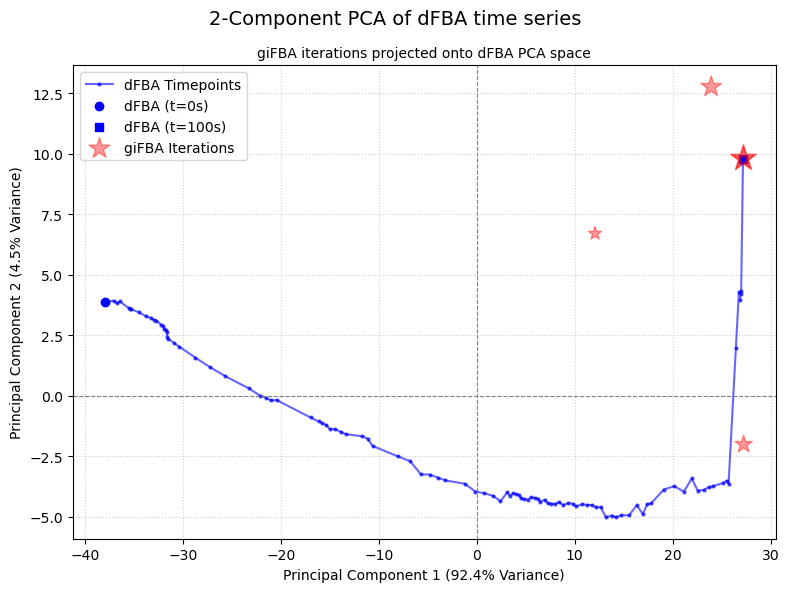

In [13]:
X_train = timeseries_df_flat.values.astype(float)
# X_test = org_flux_flat.values.reshape(-1, 1).astype(float)  # Reshape to 2D for consistency
X_test = org_flux_flat.values.astype(float)  # Reshape to 2D for consistency

# run pca on flattened dfba fluxes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# apply pca to test data
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)



# display pca results
pc1_train = X_train_pca[:, 0]
pc2_train = X_train_pca[:, 1]

pc1_new = X_test_pca[:, 0]
pc2_new = X_test_pca[:, 1]

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

gifba_ms = np.linspace(100, 400, num=len(pc1_new))  # Adjust the range and number of points as needed

# Plot historical timepoints
plt.figure(figsize=(8, 6))
plt.plot(pc1_train, pc2_train, c="blue", alpha=0.6, marker='o', ms=2, label='dFBA Timepoints')
plt.scatter(pc1_train[0], pc2_train[0], c="blue", marker="o", label='dFBA (t=0s)')
plt.scatter(pc1_train[-1], pc2_train[-1], c="blue", marker="s", label=f'dFBA (t={sol.t[-1]:.0f}s)')
plt.scatter(pc1_new, pc2_new, c='red', s=gifba_ms, marker='*', alpha=0.4, label='giFBA Iterations')

# Formatting plot axes and labels
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel(f'Principal Component 1 ({var_pc1:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({var_pc2:.1f}% Variance)')
plt.suptitle('2-Component PCA of dFBA time series', fontsize=14)
plt.title('giFBA iterations projected onto dFBA PCA space', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
# 
plt.show()

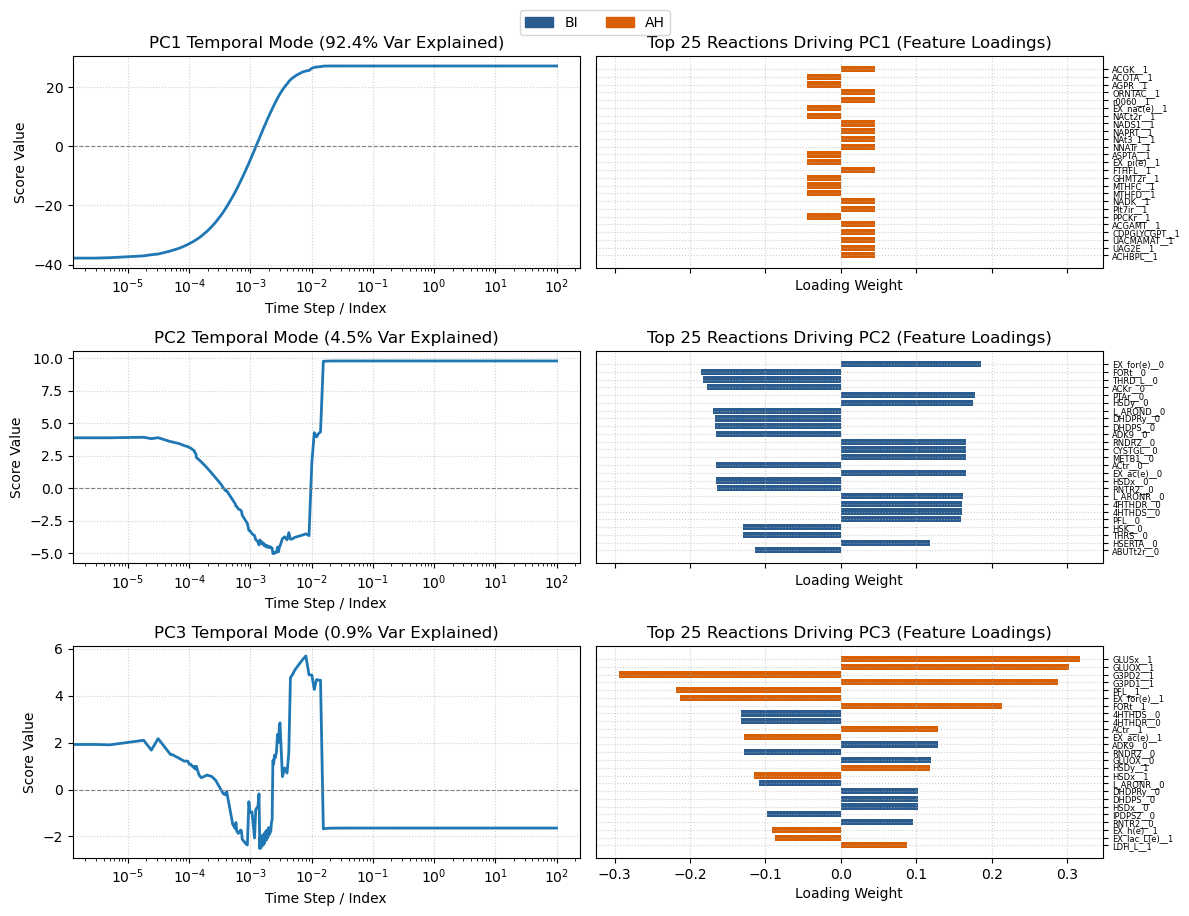

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

#  Parameters 
n_components = 3
n_rxns_shown = 25
show_rxn_names = True
data_used = "dfba"  # "dfba" or "gifba"
rxn_name_size = 6


# Color mapping for microbes based on suffix
microbe_colors = {
    '__0': '#2b5c8f',  # Microbe 0 Color
    '__1': '#d95f02',  # Microbe 1 Color
}
default_color = '#7570b3'

#  PCA Transformation 
if data_used == "dfba":
    data = X_train
    idx = timeseries_df_flat.index
    cols = timeseries_df_flat.columns
    x_scale = "log"
else:
    data = X_test
    idx = org_flux_flat.index
    cols=org_flux_flat.columns
    x_scale = "linear"
    

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
pca = PCA(n_components=n_components)
data_pca = pca.fit_transform(data_scaled)


#  DataFrames for easy plotting
pc_names = [f'PC{i+1}' for i in range(n_components)]

scores_df = pd.DataFrame(
    data_pca,
    index=idx,
    columns=[f'{pc}_Activation' for pc in pc_names],
)

loadings_df = pd.DataFrame(
    pca.components_,
    columns=cols,
    index=[f'{pc}_Loading' for pc in pc_names],
).T

# --- Helper Function for Microbe Colors ---
def get_reaction_color(rxn_id):
    for suffix, color in microbe_colors.items():
        if str(rxn_id).endswith(suffix):
            return color
    return default_color


# --- Plotting ---
fig, axes = plt.subplots(
    n_components, 2, figsize=(12, 3 * n_components), sharex='col'
)

# Handle 1D array case if n_components == 1
if n_components == 1:
    axes = np.expand_dims(axes, axis=0)

time_axis = idx

for i, pc in enumerate(pc_names):
    # Left Column: Temporal Activations
    ax_time = axes[i, 0]
    ax_time.plot(time_axis, scores_df[f'{pc}_Activation'], linewidth=2)
    var_exp = pca.explained_variance_ratio_[i] * 100
    ax_time.set_title(f'{pc} Temporal Mode ({var_exp:.1f}% Var Explained)')
    ax_time.set_ylabel('Score Value')
    ax_time.set_xscale(x_scale)
    ax_time.grid(True, linestyle=':', alpha=0.6)
    ax_time.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax_time.tick_params(labelbottom=True, bottom=True)
    ax_time.set_xlabel('Time Step / Index')

    # Right Column: Top Contributing Reactions
    ax_loadings = axes[i, 1]
    top_rxns = list(loadings_df[f'{pc}_Loading'].abs().nlargest(n_rxns_shown).index)[::-1]
    top_loadings = loadings_df.loc[top_rxns, f'{pc}_Loading']

    # Map colors based on reaction suffix (__0 vs __1)
    bar_colors = [get_reaction_color(rxn) for rxn in top_rxns]

    ax_loadings.barh(top_rxns, top_loadings, color=bar_colors)
    ax_loadings.set_title(
        f'Top {n_rxns_shown} Reactions Driving {pc} (Feature Loadings)'
    )
    ax_loadings.set_xlabel('Loading Weight')
    if show_rxn_names:
        ax_loadings.tick_params(labelleft=False, left=False, right=True, labelright=True, axis='y', 
                                labelsize=rxn_name_size)
        # put y axis tick labels right
    else:
        ax_loadings.set_yticks([])
    ax_loadings.grid(True, linestyle=':', alpha=0.6)

# Set common X-label for the bottom-left plot
axes[-1, 0].set_xlabel('Time Step / Index')

# Legend for Microbe Colors
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=f'{ids_list[int(suffix.replace("_", ""))]}')
    for suffix, color in microbe_colors.items()
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(microbe_colors),
)

plt.tight_layout()
plt.show()

In [15]:
# print(m_keys)
for i, metabolite in enumerate(m_keys):
    if "bio" in metabolite.lower():
        print(f"Biomass metabolite found: {metabolite} at index {i}")

Biomass metabolite found: EX_biomass(e)_1 at index 130
Biomass metabolite found: EX_biomass(e)_2 at index 153


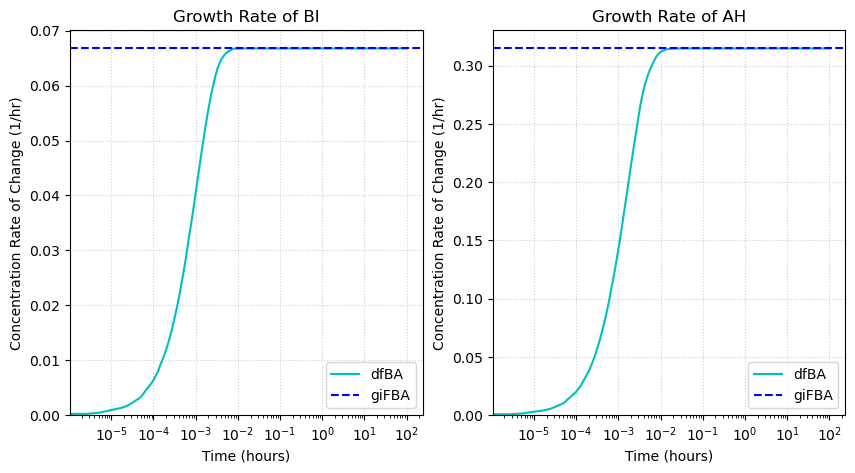

Simulating ODE: 100%|██████████| 100.0/100 [08:20<00:00, 12.97it/s]

In [ ]:
# plot each metabolite's concentration over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=False)
for i, metabolite in enumerate(m_keys):
    if "bio" in metabolite.lower():
        org_idx = int(metabolite[-1])-1

        # plot dfba
        slope = np.gradient(sol.y[i], sol.t)
        ax[org_idx].plot(sol.t, slope, label='dfBA', color='c')

        # plot gifba
        growth = org_flux[metabolite]
        ax[org_idx].axhline(growth[org_idx], label='giFBA', color='b', linestyle='--')


        # annotate
        ax[org_idx].set_xlabel('Time (hours)')
        ax[org_idx].set_ylabel('Concentration Rate of Change (1/hr)')
        ax[org_idx].set_title(f'Growth Rate of {ids_list[org_idx]}')
        ax[org_idx].set_xscale('log')
        ax[org_idx].legend()
        ax[org_idx].grid(True, linestyle=':', alpha=0.6)
        ax[org_idx].set_ylim(bottom=0)
